# Introducción

El presente análisis tiene como objetivo evaluar los resultados de la prueba A/B **recommender_system_test**, llevada a cabo por una tienda en línea internacional entre el 7 y el 21 de diciembre de 2020.

La prueba busca determinar si la introducción de un sistema de recomendaciones mejorado genera un incremento de al menos 10% en la conversión de usuarios en cada etapa del embudo: vistas de página de producto (`product_page`), adición al carrito (`product_card`) y compras (`purchase`).

Antes de analizar los resultados, se verificará que la prueba fue ejecutada correctamente, revisando posibles contaminaciones de muestra, solapamiento con eventos de marketing y distribución equitativa entre grupos.

# Preparación de los datos 

Comenzamos importando nuestras librerías y cargando los DataSets

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest

In [39]:
marketing_events = pd.read_csv("datasets/ab_project_marketing_events_us.csv")
ab_events = pd.read_csv("datasets/final_ab_events_upd_us.csv")
new_users = pd.read_csv("datasets/final_ab_new_users_upd_us.csv")
participants = pd.read_csv("datasets/final_ab_participants_upd_us.csv")

# Exploración de los datos

A continuación utilizaremos los métodos `.info()`, `.head()` y `.tail()` para obtener información inicial sobre nuestros DataFrames y buscaremos valores duplicados y nulos

## marketing_events

In [40]:
marketing_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


In [41]:
marketing_events.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [42]:
marketing_events.tail()

,name,regions,start_dt,finish_dt
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07
11,Dragon Boat Festival Giveaway,APAC,2020-06-25,2020-07-01
12,Single's Day Gift Promo,APAC,2020-11-11,2020-11-12
13,Chinese Moon Festival,APAC,2020-10-01,2020-10-07


In [43]:
marketing_events.duplicated().sum()

np.int64(0)

El dataset `marketing_events` consta de cuatro columnas y 14 filas. Contiene el calendario de eventos de marketing para 2020

No hay valores nulos ni duplicados, hace falta cambiar el tipo de datos de las columnas `start_dt` y `finish_dt` a datetime

## ab_events

In [44]:
ab_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


In [45]:
ab_events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [46]:
ab_events.tail()

,user_id,event_dt,event_name,details
423756,245E85F65C358E08,2020-12-30 19:35:55,login,NaN
423757,9385A108F5A0A7A7,2020-12-30 10:54:15,login,NaN
423758,DB650B7559AC6EAC,2020-12-30 10:59:09,login,NaN
423759,F80C9BDDEA02E53C,2020-12-30 09:53:39,login,NaN
423760,7AEC61159B672CC5,2020-12-30 11:36:13,login,NaN


In [47]:
ab_events.duplicated().sum()

np.int64(0)

El dataset `ab_events` contiene cuatro columnas y 423761 filas. Contiene información sobre los eventos realizados por los usuarios dentro de la tienda.

No cuenta con valores nulos a excepción de la columna `details` lo que es de esperarse debido a que solo los eventos *purchase* registran información (el tamaño de compra). Se conservaran para realizar cálculos sobre el tamaño de las compras. 

Tampoco hay valores duplicados.

Se debe cambiar el tipo de datos de la columna `event_dt` a datetime

## new_users

In [48]:
new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [49]:
new_users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [50]:
new_users.tail()

,user_id,first_date,region,device
58698,1DB53B933257165D,2020-12-20,EU,Android
58699,538643EB4527ED03,2020-12-20,EU,Mac
58700,7ADEE837D5D8CBBD,2020-12-20,EU,PC
58701,1C7D23927835213F,2020-12-20,EU,iPhone
58702,8F04273BB2860229,2020-12-20,EU,Android


In [51]:
new_users.duplicated().sum()

np.int64(0)

Verificamos la existencia de duplicados implícitos

In [52]:
new_users["user_id"].duplicated().sum()

np.int64(0)

El DataFrame `new_users` contiene cuatro columnas y 58703 filas. Contiene información sobre la ubicación, dispositivo y fecha de inscripción de cada usuario.

No hay valores nulos ni duplicados implícitos o explícitos

El tipo de datos de la columna `first_date` debe cambiarse a datetime

## participants

In [53]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


In [54]:
participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [55]:
participants.tail()

,user_id,group,ab_test
14520,1D302F8688B91781,B,interface_eu_test
14521,3DE51B726983B657,A,interface_eu_test
14522,F501F79D332BE86C,A,interface_eu_test
14523,63FBE257B05F2245,A,interface_eu_test
14524,79F9ABFB029CF724,B,interface_eu_test


In [56]:
participants.duplicated().sum()

np.int64(0)

Verificamos si existen usuarios registrados en ambos grupos

In [57]:
users_in_both_groups = participants.groupby("user_id")["group"].nunique()

users_in_both_groups = users_in_both_groups[users_in_both_groups > 1]

print(f"Hay {len(users_in_both_groups)} usuarios en ambos grupos")

Hay 441 usuarios en ambos grupos


El DataFrame `participants` contiene tres columnas y 14525 filas. Contiene información sobre el grupo y prueba a la que pertenece cada participante. 

En vista de que el presente análisis esta enfocado en la prueba **recommender_system_test** filtraremos nuestro DataFrame para conservar unicamente a los participantes de esa prueba

No cuenta con valores nulos ni duplicados explícitos sin embargo existen 441 registros de participantes en ambos grupos. Estos podrían ser participantes registrados en mas de una prueba A/B, lo verificaremos después de filtrar las pruebas. 

# Procesamiento de los datos

Definimos una función para cambiar el tipo de datos de las columnas referentes a fechas de cada DataFrame

In [58]:
def to_date(df, col):
    df[col] = pd.to_datetime(df[col])
    print(df[col].dtype)

## marketing_events

Cambiamos el tipo de datos de las columnas `start_dt` y `finish_dt`

In [59]:
to_date(marketing_events, "start_dt")
to_date(marketing_events, "finish_dt")

datetime64[ns]
datetime64[ns]


## ab_events

Convertimos el tipo de datos de la columna `event_dt` 

In [60]:
to_date(ab_events, "event_dt")

datetime64[ns]


## new_users

Convertimos el tipo de datos de la columna `first_date`

In [61]:
to_date(new_users, "first_date")

datetime64[ns]


## participants

Filtramos a los usuarios que no participan en la prueba **recommender_system_test**

In [62]:
participants = participants[participants["ab_test"] == "recommender_system_test"]

print(f"Total participantes: {len(participants)}")

Total participantes: 3675


Verificamos si existen usuarios registrados en ambos grupos

In [63]:
users_in_both_groups = participants.groupby("user_id")["group"].nunique()

users_in_both_groups = users_in_both_groups[users_in_both_groups > 1]

print(f"Hay {len(users_in_both_groups)} usuarios en ambos grupos")

Hay 0 usuarios en ambos grupos


Revisamos la cantidad de usuarios en cada grupo

In [64]:
users_by_group = participants.groupby("group")["user_id"].nunique()

print(users_by_group)

group
A    2747
B     928
Name: user_id, dtype: int64


Los grupos están muy desbalanceados lo que podria deberse a que hay usuarios de otras regiones y periodos registrados, para filtrarlos comenzaremos fusionando nuestros DataFrames `participants` y `new_users`

In [65]:
ab_data = participants.merge(new_users, on="user_id", how="left")

print(len(ab_data))

3675


A continuación, filtramos a los participantes que no pertenezcan a **EU**

In [66]:
ab_data = ab_data[ab_data["region"] == "EU"]

Verificamos la cantidad de participantes por grupo

In [67]:
users_by_group_clean = ab_data.groupby("group")["user_id"].nunique()

print(users_by_group_clean)

group
A    2604
B     877
Name: user_id, dtype: int64


Verificamos que los usuarios correspondan al periodo de la prueba

In [68]:
print(ab_data["first_date"].min())
print(ab_data["first_date"].max())


2020-12-07 00:00:00
2020-12-21 00:00:00


Tras filtrar por región (EU) y verificar el período de registro, el desbalance entre grupos persiste: grupo A con 2,604 usuarios y grupo B con 877. Este desbalance no tiene una explicación clara en los datos disponibles y representa una limitación importante de la prueba. Los resultados deben interpretarse con cautela ya que la diferencia en tamaño muestral puede influir en la significancia estadística.

Los 194 usuarios que se perdieron probablemente eran usuarios sin region registrada.

# Análisis exploratorio de los datos (EDA)

## Conversión en las diferentes etapas del embudo

Creamos nuestro embudo

In [69]:
recommender_ab = ab_data.merge(ab_events[["user_id", "event_name"]], on="user_id", how="left")

In [70]:
funnel = recommender_ab.groupby("event_name")["user_id"].nunique().reset_index()

print(funnel)

     event_name  user_id
0         login     3480
1  product_cart     1026
2  product_page     2178
3      purchase     1082


Existen mas usuarios en `purchase` que en `product_cart` cuando lo correcto debería ser al revés.

Verificamos si esto se presenta en ambos grupos 

In [71]:
funnel_by_group = recommender_ab.groupby(["group", "event_name"])["user_id"].nunique().reset_index()
print(funnel_by_group)

  group    event_name  user_id
0     A         login     2604
1     A  product_cart      782
2     A  product_page     1685
3     A      purchase      833
4     B         login      876
5     B  product_cart      244
6     B  product_page      493
7     B      purchase      249


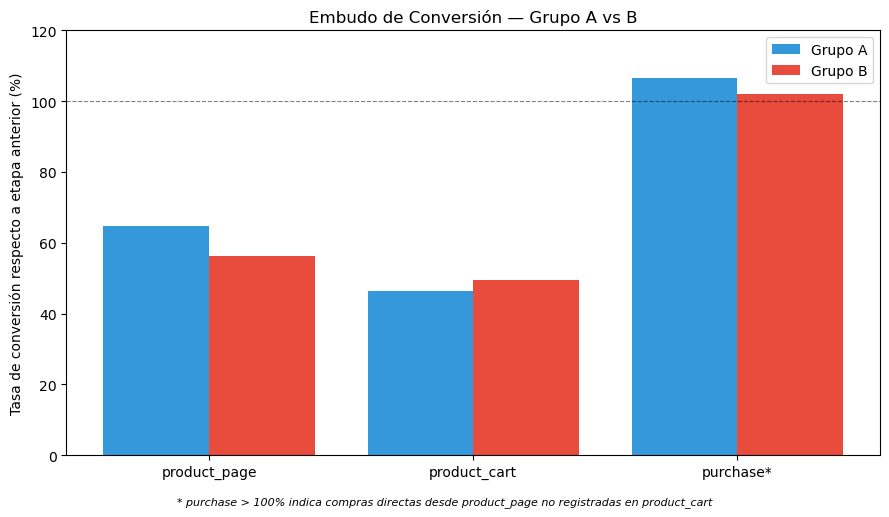

In [ ]:
etapas = ["product_page", "product_cart", "purchase*"]
valores_a = [64.7, 46.4, 106.5]
valores_b = [56.3, 49.5, 102.0]

x = np.arange(len(etapas))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, valores_a, 0.4, label="Grupo A", color="#3498db")
ax.bar(x + 0.2, valores_b, 0.4, label="Grupo B", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(etapas)
ax.set_ylabel("Tasa de conversión respecto a etapa anterior (%)")
ax.set_title("Embudo de Conversión — Grupo A vs B")
ax.legend()
ax.set_ylim(0, 120)
ax.axhline(y=100, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
plt.figtext(0.5, -0.02, 
            "* purchase > 100% indica compras directas desde product_page no registradas en product_cart", 
            ha="center", fontsize=8, style="italic")
plt.tight_layout()
plt.show()

Se identificó una anomalía en ambos grupos: en el *grupo A* hay **833** usuarios en `purchase` vs **782** en `product_cart`, y en el *grupo B* hay **249** vs **244** respectivamente. Esto indica que algunos usuarios realizaron compras directamente desde `product_page` sin pasar por `product_cart`, lo cual podría ser una funcionalidad de compra directa no documentada o un error de registro. Al ser diferencias marginales respecto al total de participantes, no se eliminarán estos registros.

Con esto establecido, procedemos con el calculo de la conversión en cada etapa del embudo por grupo

In [72]:
funnel_order = ["login", "product_page", "product_cart", "purchase"]

for group in ["A", "B"]:
    group_funnel = funnel_by_group[funnel_by_group["group"] == group].set_index("event_name")["user_id"]
    group_funnel = group_funnel[funnel_order]
    conversion = group_funnel / group_funnel.shift(1)
    print(f"\nGrupo {group}:")
    print(conversion)


Grupo A:
event_name
login                NaN
product_page    0.647081
product_cart    0.464095
purchase        1.065217
Name: user_id, dtype: float64

Grupo B:
event_name
login                NaN
product_page    0.562785
product_cart    0.494929
purchase        1.020492
Name: user_id, dtype: float64


El hecho de que purchase sea mayor a uno en ambos grupos confirma la anomalía que vimos antes donde hay más compradores que usuarios en `product_cart`

El *grupo A* convierte mejor de `login` a `product_page` (**64.7% vs 56.3%**)

El *grupo B* convierte mejor de `product_page` a `product_cart` (**49.5% vs 46.4%**)

Calculemos la diferencia relativa que existe entre las conversiones de ambos grupos

In [73]:
conversion_a = pd.Series({
    "product_page": 0.647081,
    "product_cart": 0.464095,
    "purchase": 1.065217
})

conversion_b = pd.Series({
    "product_page": 0.562785,
    "product_cart": 0.494929,
    "purchase": 1.020492
})

relative_diff = (conversion_b - conversion_a) / conversion_a * 100
print(relative_diff)

product_page   -13.027117
product_cart     6.643898
purchase        -4.198675
dtype: float64


El grupo B no cumple el objetivo de mejora del 10% en ninguna etapa del embudo. En product_page el grupo B tiene un 13% menos de conversión que el grupo A, en product_cart mejora un 6.6% pero sin alcanzar el umbral requerido, y en purchase es un 4.2% inferior. El desbalance entre grupos (2,604 vs 877 usuarios) puede estar influyendo en estas tasas, por lo que las diferencias deben validarse mediante pruebas estadísticas antes de sacar conclusiones definitivas.

## ¿El número de eventos por usuario está distribuido equitativamente entre grupos?

Unimos `ab_events` con `ab_data` para conservar unicamente los eventos de los usuarios que participaron en el test 

In [74]:
recommender_ab = ab_data.merge(ab_events, on="user_id", how="left")

Contamos los eventos por usuario de cada grupo

In [75]:
events_by_group = recommender_ab.groupby(["group", "user_id"])["event_name"].count()
print(events_by_group.groupby("group").mean())

group
A    6.785714
B    5.705815
Name: event_name, dtype: float64


A pesar de contar con menos usuarios, el grupo B presenta un promedio de eventos por usuario (5.71) cercano al del grupo A (6.79). Esto podría indicar una mayor actividad individual en el grupo B, aunque también podría ser el resultado de unos pocos usuarios con un volumen de eventos muy superior al resto. 

Creamos un diagrama de caja para verificar si es comportamiento generalizado o pocos usuarios muy activos.

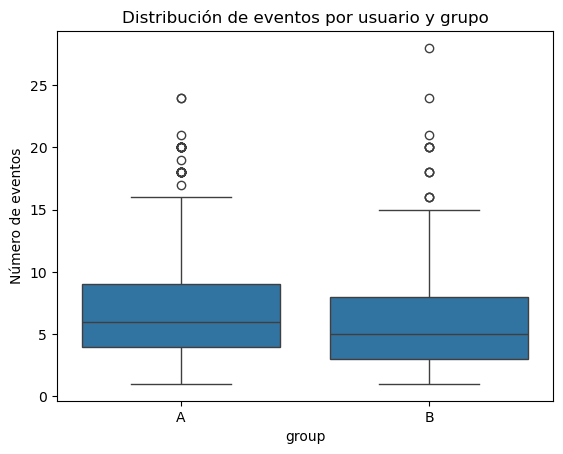

In [ ]:
sns.boxplot(data=events_by_group.reset_index(), x="group", y="event_name")
plt.title("Distribución de eventos por usuario y grupo")
plt.ylabel("Número de eventos")
plt.show()

Existen valores atípicos en ambos grupos, sin embargo estos afectan poco a los datos ya que las medianas de ambos grupos están cerca de sus valores medios. La distribución de eventos por usuario es bastante similar entre grupos, lo que confirma que la actividad del grupo B es real y no depende únicamente de unos pocos usuarios atípicos. Sin embargo, esto no compensa el desbalance en el número de participantes (2,604 vs 877), que sigue siendo una limitación importante de la prueba.

## Distribución de eventos por día

Comenzamos creando una columna que contenga unicamente la fecha del evento sin la hora

In [77]:
recommender_ab["event_date"] = recommender_ab["event_dt"].dt.date

Contamos la cantidad de eventos por día de cada grupo y graficamos el resultado

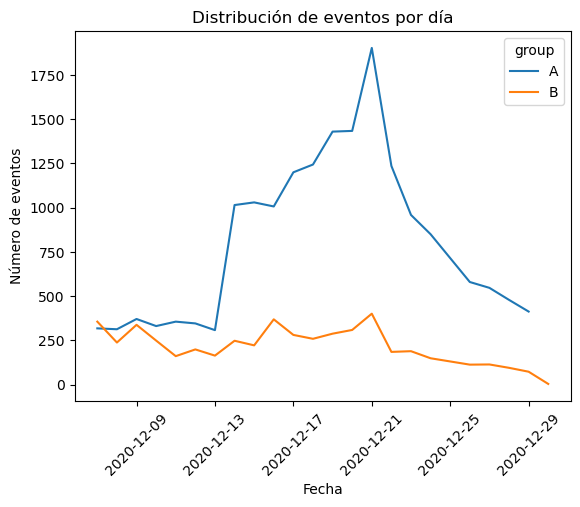

In [ ]:
events_by_day = recommender_ab.groupby(["event_date", "group"])["event_name"].count().reset_index()

sns.lineplot(data=events_by_day, x="event_date", y="event_name", hue="group")
plt.title("Distribución de eventos por día")
plt.xlabel("Fecha")
plt.ylabel("Número de eventos")
plt.xticks(rotation=45)
plt.show()

La distribución de eventos por día muestra que el grupo A genera consistentemente más eventos que el grupo B, lo cual es atribuible principalmente al mayor número de participantes en ese grupo. El grupo B presenta un comportamiento más estable a lo largo del tiempo.

Se observa un pico de actividad el 21 de diciembre en ambos grupos, fecha que coincide con el último día de registro de nuevos usuarios. La caída de actividad posterior a esa fecha es esperada y no representa una anomalía, ya que refleja la ausencia de nuevos participantes entrando al sistema.

Ambos grupos muestran una caída simultánea al final del período, lo que sugiere un comportamiento orgánico similar entre grupos independientemente del tamaño muestral.

## Peculiaridades en los datos

Antes de realizar las pruebas estadisticas es necesario identificar peculiaridades en los datos que pudieran afectar el resultado de nuestras pruebas, hasta ahora se ha identificado:

- Desbalance entre grupos (2,604 vs 877)
- Dos pruebas en el mismo dataset

Ambas peculiaridades han sido documentadas y resueltas en su caso, sin embargo aun debemos explorar si existen eventos de Marketing que pudieron afectar al comportamiento de los usuarios 

Verificamos si hubo algún evento en la region de Europa durante las fechas de recolección de participantes

In [79]:
eu_marketing = marketing_events[(marketing_events["regions"].str.contains("EU")) & (marketing_events["start_dt"] <= "2021-01-01") & (marketing_events["finish_dt"] >= "2020-12-07")]

eu_marketing

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


El evento *Christmas&New Year Promo* estuvo activo desde el 25 de Diciembre hasta poco después de finalizada la recavación de datos para nuestra prueba. El comportamiento de los usuarios pudo verse afectado por ese evento.

Calculemos el porcentaje de eventos que se registraron despues del 25 de diciembre

In [80]:
dic_25 = recommender_ab[recommender_ab["event_date"] >= pd.Timestamp("2020-12-25").date()]

print(len(dic_25) / len(recommender_ab) * 100)

10.664196877480816


Los eventos registrados a partir del 25 de diciembre representan el 10.6% del total, período que coincide con la campaña 'Christmas & New Year Promo' activa en la región EU. Si bien lo ideal sería filtrar estos datos para evitar la contaminación de la campaña, el desbalance existente entre grupos (2,604 vs 877 usuarios) hace que eliminar un 10.6% adicional pueda comprometer aún más la comparabilidad entre grupos. Por esta razón se conservan los datos completos, pero los resultados del período 25 dic - 1 ene deben interpretarse con cautela.

# Evaluación estadística de resultados del test A/B

Para determinar si las diferencias observadas en el embudo de conversión entre los grupos A y B son estadísticamente significativas, se realizarán pruebas Z de proporciones para cada etapa del embudo: product_page, product_cart y purchase.

Dado que se realizarán 3 pruebas de hipótesis, se aplica la corrección de Bonferroni ajustando el nivel de significancia a 0.05/3 = 0.017. Una diferencia se considerará estadísticamente significativa únicamente si el p-value es inferior a este umbral

In [81]:
alpha = 0.05 / 3  

for event in ["product_page", "product_cart", "purchase"]:
    successes = [
        funnel_by_group[funnel_by_group["group"] == "A"].set_index("event_name").loc[event, "user_id"],
        funnel_by_group[funnel_by_group["group"] == "B"].set_index("event_name").loc[event, "user_id"]
    ]
    nobs = [users_by_group_clean["A"], users_by_group_clean["B"]]
    
    stat, p_value = proportions_ztest(successes, nobs)
    print(f"{event}: p-value = {p_value} {'✓ Significativo' if p_value < alpha else '✗ No significativo'}")

product_page: p-value = 6.94273935952599e-06 ✓ Significativo
product_cart: p-value = 0.21469192029582396 ✗ No significativo
purchase: p-value = 0.04652482738393029 ✗ No significativo


Las pruebas Z con corrección de Bonferroni (**α = 0.017**) arrojaron los siguientes resultados:

- `product_page`: diferencia estadísticamente significativa (**p = 6.94e-06**), sin embargo el grupo B convierte un 13% menos que el grupo A, lo que va en contra del objetivo del test.
- `product_cart`: sin diferencia significativa (**p = 0.215**), el grupo B mejora un 6.6% pero no alcanza el umbral del 10% requerido.
- `purchase`: sin diferencia significativa (**p = 0.047**), el grupo B es un 4.2% inferior al grupo A.

El test A/B no cumplió su objetivo. El sistema de recomendaciones no demostró mejorar la conversión en ninguna etapa del embudo en al menos un 10%. La única diferencia estadísticamente significativa encontrada fue en product_page, pero en dirección contraria a la esperada.

El desbalance entre grupos (**2,604 vs 877**) y el solapamiento con la campaña de marketing de diciembre representan limitaciones importantes que podrían haber influido en los resultados. Se recomienda repetir el test con grupos balanceados y fuera de períodos de campañas activas antes de tomar una decisión definitiva sobre el sistema de recomendaciones.

# Conclusión

El análisis del test A/B **recommender_system_test** reveló múltiples problemas en la ejecución de la prueba que comprometen la validez de sus resultados: un desbalance significativo entre grupos (**2,604 usuarios en A vs 877 en B**), la coexistencia de dos pruebas en el mismo dataset, 194 participantes sin registro de región verificable, y un solapamiento de 7 días con la campaña *'Christmas & New Year Promo'* en la región EU.

Los resultados del embudo muestran que el grupo B no alcanzó la mejora del 10% requerida en ninguna etapa. La única diferencia estadísticamente significativa encontrada fue en `product_page`, pero en dirección contraria al objetivo: el grupo B convirtió un 13% menos que el grupo A.

Se recomienda no implementar el sistema de recomendaciones basándose en esta prueba, y repetir el experimento bajo condiciones más controladas: grupos balanceados, un único test activo por período, y fechas alejadas de campañas de marketing.